In [33]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adrivg/ravdess-emotional-speech-video")

print("Path to dataset files:", path)

Resuming download from 13259243520 bytes (89575060 bytes left)...
Resuming download from https://www.kaggle.com/api/v1/datasets/download/adrivg/ravdess-emotional-speech-video?dataset_version_number=1 (13259243520/13348818580) bytes left.


100%|██████████| 12.4G/12.4G [01:07<00:00, 1.33MB/s]

Extracting files...


Path to dataset files: /Users/robamahmoud/.cache/kagglehub/datasets/adrivg/ravdess-emotional-speech-video/versions/1


In [7]:
import os
import pandas as pd

# Define the dataset path
dataset_path = "/Users/robamahmoud/.cache/kagglehub/datasets/adrivg/ravdess-emotional-speech-video/versions/1"

# Initialize a list to store file metadata
data = []

# Map emotion codes to labels
emotion_map = {
    "01": "neutral",
    "03": "happy",
    "04": "sad"
}

# Traverse the directory to collect relevant files
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav") or file.endswith(".mp4"):  # Assuming audio and video files
            parts = file.split("-")
            if len(parts) > 2:  # Ensure file naming convention matches
                emotion_code = parts[2]
                if emotion_code in emotion_map:  # Only include relevant emotions
                    emotion_label = emotion_map[emotion_code]
                    full_path = os.path.join(root, file)
                    data.append({
                        "file_path": full_path,
                        "emotion": emotion_label,
                        "file_type": "audio" if file.endswith(".wav") else "video"
                    })

# Convert to DataFrame
df = pd.DataFrame(data)

# Display the first few rows of the DataFrame
print(df.head())

# Save the DataFrame for later use if needed
df.to_csv("ravdess_filtered_dataset.csv", index=False)
df

                                           file_path emotion file_type
0  /Users/robamahmoud/.cache/kagglehub/datasets/a...     sad     video
1  /Users/robamahmoud/.cache/kagglehub/datasets/a...     sad     video
2  /Users/robamahmoud/.cache/kagglehub/datasets/a...     sad     video
3  /Users/robamahmoud/.cache/kagglehub/datasets/a...     sad     video
4  /Users/robamahmoud/.cache/kagglehub/datasets/a...   happy     video


,file_path,emotion,file_type
0,/Users/robamahmoud/.cache/kagglehub/datasets/a...,sad,video
1,/Users/robamahmoud/.cache/kagglehub/datasets/a...,sad,video
2,/Users/robamahmoud/.cache/kagglehub/datasets/a...,sad,video
3,/Users/robamahmoud/.cache/kagglehub/datasets/a...,sad,video
4,/Users/robamahmoud/.cache/kagglehub/datasets/a...,happy,video
...,...,...,...
955,/Users/robamahmoud/.cache/kagglehub/datasets/a...,happy,video
956,/Users/robamahmoud/.cache/kagglehub/datasets/a...,happy,video
957,/Users/robamahmoud/.cache/kagglehub/datasets/a...,neutral,video
958,/Users/robamahmoud/.cache/kagglehub/datasets/a...,happy,video


In [8]:
df.drop("file_type", axis=1, inplace=True)
df.to_csv("ravdess_filtered_dataset.csv", index=False)

In [9]:
%pip install deepface

Note: you may need to restart the kernel to use updated packages.


In [10]:
import os
import cv2
import pandas as pd

# Path to CSV file
csv_file = "ravdess_filtered_dataset.csv"  # Example CSV: columns - ['file_path', 'emotion']

# Output directories
output_dir = "extracted_frames"
os.makedirs(output_dir, exist_ok=True)

# Mapping file path
mapping_file = "frame_mapping.csv"
frame_mappings = []

# Function to extract frames
def extract_frames(video_path, emotion_label, output_dir, interval=30):
    """Extract frames from a video and save them."""
    cap = cv2.VideoCapture(video_path)
    frame_count = 0
    saved_frames = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        # Save frame every 'interval' frames
        if frame_count % interval == 0:
            # Create a directory for the emotion label if it doesn't exist
            emotion_dir = os.path.join(output_dir, emotion_label)
            os.makedirs(emotion_dir, exist_ok=True)

            # Save the frame as an image
            video_name = os.path.splitext(os.path.basename(video_path))[0]
            frame_filename = f"{video_name}_frame{frame_count}.jpg"
            frame_path = os.path.join(emotion_dir, frame_filename)
            cv2.imwrite(frame_path, frame)

            # Add entry to the mapping file
            frame_mappings.append({
                "frame_path": frame_path,
                "video_path": video_path,
                "emotion": emotion_label
            })

            saved_frames += 1

        frame_count += 1

    cap.release()
    return saved_frames

# Process each video
for index, row in pd.read_csv(csv_file).iterrows():
    video_path = row['file_path']
    emotion_label = row['emotion']

    if not os.path.exists(video_path):
        print(f"File not found: {video_path}")
        continue

    print(f"Processing video: {video_path}")

    # Extract and save frames
    frames_saved = extract_frames(video_path, emotion_label, output_dir)
    print(f"Saved {frames_saved} frames for video: {video_path}")

# Save the mapping file as CSV
pd.DataFrame(frame_mappings).to_csv(mapping_file, index=False)
print(f"Frame mapping saved to {mapping_file}")


Processing video: /Users/robamahmoud/.cache/kagglehub/datasets/adrivg/ravdess-emotional-speech-video/versions/1/RAVDESS dataset/Video_Speech_Actor_02/Actor_02/01-01-04-01-01-01-02.mp4
Saved 4 frames for video: /Users/robamahmoud/.cache/kagglehub/datasets/adrivg/ravdess-emotional-speech-video/versions/1/RAVDESS dataset/Video_Speech_Actor_02/Actor_02/01-01-04-01-01-01-02.mp4
Processing video: /Users/robamahmoud/.cache/kagglehub/datasets/adrivg/ravdess-emotional-speech-video/versions/1/RAVDESS dataset/Video_Speech_Actor_02/Actor_02/01-01-04-02-02-01-02.mp4
Saved 4 frames for video: /Users/robamahmoud/.cache/kagglehub/datasets/adrivg/ravdess-emotional-speech-video/versions/1/RAVDESS dataset/Video_Speech_Actor_02/Actor_02/01-01-04-02-02-01-02.mp4
Processing video: /Users/robamahmoud/.cache/kagglehub/datasets/adrivg/ravdess-emotional-speech-video/versions/1/RAVDESS dataset/Video_Speech_Actor_02/Actor_02/02-01-04-01-01-02-02.mp4
Saved 4 frames for video: /Users/robamahmoud/.cache/kagglehub/da

In [11]:
import pandas as pd

# Load the CSV file
csv_file_path = "frame_mapping.csv"
data = pd.read_csv(csv_file_path)

# Preview the first few rows
print(data.head())


                                          frame_path  \
0  extracted_frames/sad/01-01-04-01-01-01-02_fram...   
1  extracted_frames/sad/01-01-04-01-01-01-02_fram...   
2  extracted_frames/sad/01-01-04-01-01-01-02_fram...   
3  extracted_frames/sad/01-01-04-01-01-01-02_fram...   
4  extracted_frames/sad/01-01-04-02-02-01-02_fram...   

                                          video_path emotion  
0  /Users/robamahmoud/.cache/kagglehub/datasets/a...     sad  
1  /Users/robamahmoud/.cache/kagglehub/datasets/a...     sad  
2  /Users/robamahmoud/.cache/kagglehub/datasets/a...     sad  
3  /Users/robamahmoud/.cache/kagglehub/datasets/a...     sad  
4  /Users/robamahmoud/.cache/kagglehub/datasets/a...     sad  


In [12]:
import pandas as pd
from torch.utils.data import Dataset
from PIL import Image

class FrameDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        """
        Args:
            csv_file (str): Path to the CSV file containing frame paths and emotions.
            transform (callable, optional): Optional transform to be applied
                on a sample.
        """
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        self.label_to_int = {'happy': 0, 'sad': 1, 'neutral': 2}  # Map emotions to integers

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        """
        Args:
            idx (int): Index of the data sample to fetch.

        Returns:
            tuple: (image, label) where image is the transformed image tensor
                   and label is the numeric class of the emotion.
        """
        frame_path = self.data.iloc[idx]["frame_path"]
        label = self.data.iloc[idx]["emotion"]
        label = self.label_to_int[label]  # Convert label to integer

        # Load and transform the image
        image = Image.open(frame_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


In [13]:
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split
# Define your transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# Load the dataset
dataset = FrameDataset(csv_file="frame_mapping.csv", transform=transform)

# Split sizes
total_samples = len(dataset)
train_size = int(0.7 * total_samples)
val_size = int(0.15 * total_samples)
test_size = total_samples - train_size - val_size

# Split dataset
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
for i in range(5):
   image, label = dataset[i]
   print(f"Image shape: {image.shape}, Label: {label}")


Image shape: torch.Size([3, 128, 128]), Label: 1
Image shape: torch.Size([3, 128, 128]), Label: 1
Image shape: torch.Size([3, 128, 128]), Label: 1
Image shape: torch.Size([3, 128, 128]), Label: 1
Image shape: torch.Size([3, 128, 128]), Label: 1


In [14]:
print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")


Training set size: 2739
Validation set size: 586
Test set size: 588


In [15]:
import torch
import torch.nn as nn

class VideoEmotionModel(nn.Module):
    def __init__(self, num_classes):
        super(VideoEmotionModel, self).__init__()
        self.conv3d = nn.Sequential(
            nn.Conv3d(3, 32, kernel_size=(1, 3, 3), stride=(1, 2, 2), padding=(0, 1, 1)),  # Temporal kernel size = 1
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2)),  # Temporal pooling size = 1
            nn.Conv3d(32, 64, kernel_size=(1, 3, 3), stride=(1, 2, 2), padding=(0, 1, 1)),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2))
        )
        # Corrected fully connected input dimension
        self.fc_input_dim = 64 * 8 * 8  # 64 channels * 8 height * 8 width
        self.fc = nn.Sequential(
            nn.Linear(self.fc_input_dim, 512),  # Adjusted input size
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv3d(x)
        x = x.view(x.size(0), -1)  # Flatten
        return self.fc(x)


In [16]:
def forward(self, x):
    x = self.conv3d(x)
    print(f"After conv3d: {x.shape}")  # Debug line
    x = x.view(x.size(0), -1)  # Flatten
    print(f"After flatten: {x.shape}")  # Debug line
    return self.fc(x)


In [17]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms

# Ensure you have your VideoEmotionModel defined here or imported

# Hyperparameters
num_classes = 3  # Assuming 'happy', 'sad', 'neutral'
num_epochs = 3
learning_rate = 0.001

# Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VideoEmotionModel(num_classes=num_classes).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    train_losses = []  # Track training losses
    val_losses = []  # Track validation losses
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images = images.unsqueeze(2).to(device)  # Add temporal dimension (frames = 1)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        train_losses.append(train_loss / len(train_loader))
        train_accuracy = 100 * train_correct / train_total

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.unsqueeze(2).to(device)  # Add temporal dimension (frames = 1)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_losses.append(val_loss / len(val_loader))
        val_accuracy = 100 * val_correct / val_total

        # Print training and validation loss and accuracy
        print(f"Epoch [{epoch + 1}/{num_epochs}]")
        print(f"Train Loss: {train_losses[-1]:.4f}, Train Accuracy: {train_accuracy:.2f}%")
        print(f"Validation Loss: {val_losses[-1]:.4f}, Validation Accuracy: {val_accuracy:.2f}%")
        print("-" * 50)

    return train_losses, val_losses

# Run training
train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs)



Epoch [1/3]
Train Loss: 1.0380, Train Accuracy: 43.74%
Validation Loss: 0.9606, Validation Accuracy: 51.02%
--------------------------------------------------
Epoch [2/3]
Train Loss: 0.8048, Train Accuracy: 62.21%
Validation Loss: 0.5957, Validation Accuracy: 74.91%
--------------------------------------------------
Epoch [3/3]
Train Loss: 0.4961, Train Accuracy: 79.96%
Validation Loss: 0.3664, Validation Accuracy: 87.20%
--------------------------------------------------


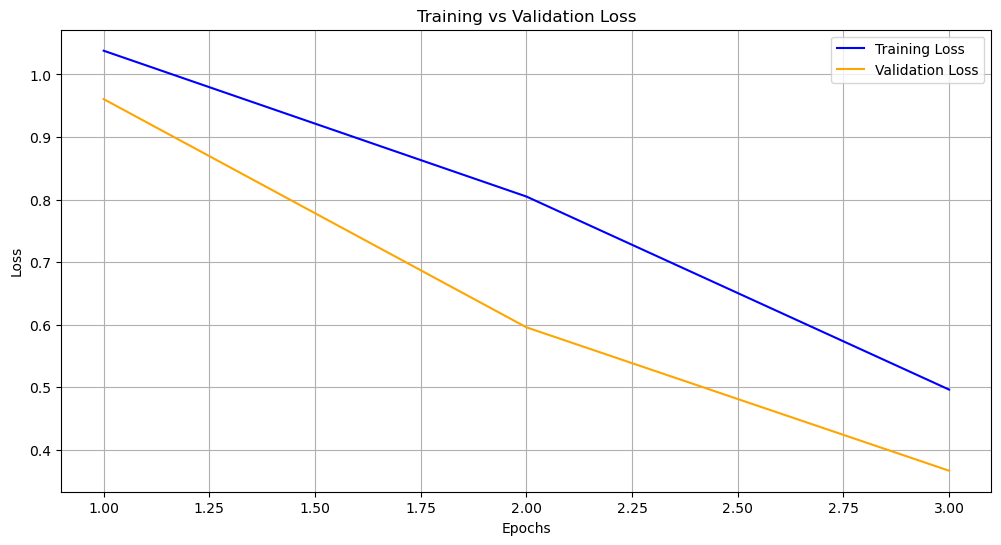

In [18]:
# Plot Training vs Validation Loss
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(12, 6))
plt.plot(epochs_range, train_losses, label="Training Loss", color="blue")
plt.plot(epochs_range, val_losses, label="Validation Loss", color="orange")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [19]:
torch.save(model.state_dict(), "video_emotion_model.pth")
print("Model saved as video_emotion_model.pth")


Model saved as video_emotion_model.pth


In [20]:
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Label mapping (update if needed)
label_mapping = {0: 'happy', 1: 'sad', 2: 'neutral'}
reverse_label_mapping = {v: k for k, v in label_mapping.items()}

def evaluate_test(model, test_dataloader, criterion, device):
    model.eval()  # Set the model to evaluation mode
    total_test_loss = 0
    all_test_labels = []
    all_test_predictions = []

    with torch.no_grad():
        for images, labels in test_dataloader:
            images = images.unsqueeze(2).to(device)  # Add temporal dimension (frames = 1)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)
            total_test_loss += loss.item()

            # Track predictions and labels
            _, predicted = torch.max(outputs, 1)
            all_test_predictions.extend(predicted.cpu().numpy())
            all_test_labels.extend(labels.cpu().numpy())

    # Calculate overall metrics
    avg_test_loss = total_test_loss / len(test_dataloader)
    test_accuracy = accuracy_score(all_test_labels, all_test_predictions)

    print(f"Test Loss: {avg_test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(all_test_labels, all_test_predictions, target_names=label_mapping.values()))

    # Confusion matrix
    print("\nConfusion Matrix:")
    cm = confusion_matrix(all_test_labels, all_test_predictions)
    print(cm)

    return avg_test_loss, test_accuracy, cm

# Evaluate the model on the test set
test_loss, test_accuracy, cm = evaluate_test(model, test_loader, criterion, device)


Test Loss: 0.3921
Test Accuracy: 0.8384

Classification Report:
              precision    recall  f1-score   support

       happy       0.87      0.80      0.83       215
         sad       0.88      0.82      0.85       260
     neutral       0.72      0.96      0.82       113

    accuracy                           0.84       588
   macro avg       0.83      0.86      0.84       588
weighted avg       0.85      0.84      0.84       588


Confusion Matrix:
[[172  25  18]
 [ 24 213  23]
 [  1   4 108]]
